In [125]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [126]:
# Cargar ambos datasets
df_general = pd.read_csv('data/raw/eurostat_desempleo_general.csv')
df_jovenes = pd.read_csv('data/raw/eurostat_desempleo_jovenes.csv')

print("Desempleo General:")
print(df_general.head())
print(f"\nTamaño: {df_general.shape}")

print("\n" + "="*50)
print("Desempleo Juvenil:")
print(df_jovenes.head())
print(f"\nTamaño: {df_jovenes.shape}")

Desempleo General:
              DATAFLOW        LAST UPDATE    freq                  age  \
0  ESTAT:TESEM120(1.0)  10/09/26 23:00:00  Annual  From 15 to 74 years   
1  ESTAT:TESEM120(1.0)  10/09/26 23:00:00  Annual  From 15 to 74 years   
2  ESTAT:TESEM120(1.0)  10/09/26 23:00:00  Annual  From 15 to 74 years   
3  ESTAT:TESEM120(1.0)  10/09/26 23:00:00  Annual  From 15 to 74 years   
4  ESTAT:TESEM120(1.0)  10/09/26 23:00:00  Annual  From 15 to 74 years   

                                           unit      sex    geo  TIME_PERIOD  \
0  Percentage of population in the labour force  Females  Spain         2015   
1  Percentage of population in the labour force  Females  Spain         2016   
2  Percentage of population in the labour force  Females  Spain         2017   
3  Percentage of population in the labour force  Females  Spain         2018   
4  Percentage of population in the labour force  Females  Spain         2019   

   OBS_VALUE OBS_FLAG  CONF_STATUS  
0       23.6      

In [127]:
# Columnas
print("COLUMNAS - Desempleo General:")
print(df_general.columns.tolist())

print("\n" + "="*50)
print("COLUMNAS - Desempleo Juvenil:")
print(df_jovenes.columns.tolist())

# Tipos de datos
print("\n" + "="*50)
print("TIPOS DE DATOS - General:")
print(df_general.dtypes)

print("\nTIPOS DE DATOS - Juvenil:")
print(df_jovenes.dtypes)

# Nulos
print("\n" + "="*50)
print("NULOS - General:")
print(df_general.isnull().sum())

print("\nNULOS - Juvenil:")
print(df_jovenes.isnull().sum())

COLUMNAS - Desempleo General:
['DATAFLOW', 'LAST UPDATE', 'freq', 'age', 'unit', 'sex', 'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS']

COLUMNAS - Desempleo Juvenil:
['DATAFLOW', 'LAST UPDATE', 'freq', 'age', 'unit', 'sex', 'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS']

TIPOS DE DATOS - General:
DATAFLOW        object
LAST UPDATE     object
freq            object
age             object
unit            object
sex             object
geo             object
TIME_PERIOD      int64
OBS_VALUE      float64
OBS_FLAG        object
CONF_STATUS    float64
dtype: object

TIPOS DE DATOS - Juvenil:
DATAFLOW        object
LAST UPDATE     object
freq            object
age             object
unit            object
sex             object
geo             object
TIME_PERIOD      int64
OBS_VALUE      float64
OBS_FLAG        object
CONF_STATUS    float64
dtype: object

NULOS - General:
DATAFLOW        0
LAST UPDATE     0
freq            0
age             0
unit            0
sex


## DESCRIPCIÓN DE LOS DATASETS

### Dataset 1: Desempleo General (15-74 años)
- Fuente: Eurostat (TESEM120)
- Período: 2015-2024 (anual)
- Países: España
- Sexo: Total, Hombre, Mujer
- Unidad: Porcentaje de la población activa
- Tamaño: 33 filas x 11 columnas

### Dataset 2: Desempleo Juvenil (15-24 años)
- Fuente: Eurostat (TESEM140)
- Período: 2015-2024 (anual)
- Países: España
- Sexo: Total, Hombre, Mujer
- Unidad: Porcentaje de la población activa
- Tamaño: 33 filas x 11 columnas

### Preguntas de Negocio

**Pregunta Principal:**
1. ¿Cuál es la tendencia del desempleo juvenil (15-24) en España 2015-2024? 
2. ¿Ha mejorado o empeorado? 
3. ¿Cuál fue el impacto del COVID-19?

**Preguntas Secundarias:**
1. ¿Existe brecha de género en el desempleo juvenil?
2. ¿Cómo ha evolucionado el desempleo general (15-74) en el mismo período?
3. ¿Qué edad es más vulnerable al desempleo?
""".format(df_general.shape[0], df_general.shape[1], df_jovenes.shape[0], df_jovenes.shape[1])

In [128]:
print("="*70)
print("DIAGNÓSTICO INICIAL - ANTES DE LIMPIAR")
print("="*70)

# DATASET GENERAL
print("\nDESEMPLEO GENERAL (15-74 años)")
print(f"Filas: {df_general.shape[0]}, Columnas: {df_general.shape[1]}")
print(f"\nNulos por columna:")
print(df_general.isnull().sum())
print(f"\nPorcentaje de nulos:")
print((df_general.isnull().sum() / len(df_general) * 100).round(2))

# DATASET JUVENIL
print("\n" + "="*70)
print("DESEMPLEO JUVENIL (15-24 años)")
print(f"Filas: {df_jovenes.shape[0]}, Columnas: {df_jovenes.shape[1]}")
print(f"\nNulos por columna:")
print(df_jovenes.isnull().sum())
print(f"\nPorcentaje de nulos:")
print((df_jovenes.isnull().sum() / len(df_jovenes) * 100).round(2))

# Valores únicos importantes
print("\n" + "="*70)
print("VALORES ÚNICOS")
print("="*70)
print(f"\nSexos (General): {df_general['sex'].unique()}")
print(f"Sexos (Juvenil): {df_jovenes['sex'].unique()}")
print(f"\nAños (General): {sorted(df_general['TIME_PERIOD'].unique())}")
print(f"Años (Juvenil): {sorted(df_jovenes['TIME_PERIOD'].unique())}")

DIAGNÓSTICO INICIAL - ANTES DE LIMPIAR

DESEMPLEO GENERAL (15-74 años)
Filas: 33, Columnas: 11

Nulos por columna:
DATAFLOW        0
LAST UPDATE     0
freq            0
age             0
unit            0
sex             0
geo             0
TIME_PERIOD     0
OBS_VALUE       0
OBS_FLAG       18
CONF_STATUS    33
dtype: int64

Porcentaje de nulos:
DATAFLOW         0.00
LAST UPDATE      0.00
freq             0.00
age              0.00
unit             0.00
sex              0.00
geo              0.00
TIME_PERIOD      0.00
OBS_VALUE        0.00
OBS_FLAG        54.55
CONF_STATUS    100.00
dtype: float64

DESEMPLEO JUVENIL (15-24 años)
Filas: 33, Columnas: 11

Nulos por columna:
DATAFLOW        0
LAST UPDATE     0
freq            0
age             0
unit            0
sex             0
geo             0
TIME_PERIOD     0
OBS_VALUE       0
OBS_FLAG       18
CONF_STATUS    33
dtype: int64

Porcentaje de nulos:
DATAFLOW         0.00
LAST UPDATE      0.00
freq             0.00
age              0.0

In [129]:
print("="*70)
print("DECISIÓN 1: SELECCIONAR COLUMNAS RELEVANTES")
print("="*70)

# Solo necesitamos: year, sex, unemployment_rate, age_group
# Las columnas DATAFLOW, LAST UPDATE, freq, unit, geo, OBS_FLAG, CONF_STATUS no aportan

print("\nColumnas originales: ", df_general.columns.tolist())
print("\nDecisión: Mantener solo las relevantes")
print("  - TIME_PERIOD → año")
print("  - sex → sexo")
print("  - OBS_VALUE → tasa de desempleo")
print("  - age → grupo de edad")

# Crear versión limpia del GENERAL
df_general_clean = df_general[['TIME_PERIOD', 'sex', 'OBS_VALUE', 'age']].copy()
df_general_clean.columns = ['year', 'sex', 'unemployment_rate', 'age_group']

# Crear versión limpia del JUVENIL
df_jovenes_clean = df_jovenes[['TIME_PERIOD', 'sex', 'OBS_VALUE', 'age']].copy()
df_jovenes_clean.columns = ['year', 'sex', 'unemployment_rate', 'age_group']

print("\n Columnas seleccionadas:")
print(df_general_clean.head())

DECISIÓN 1: SELECCIONAR COLUMNAS RELEVANTES

Columnas originales:  ['DATAFLOW', 'LAST UPDATE', 'freq', 'age', 'unit', 'sex', 'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS']

Decisión: Mantener solo las relevantes
  - TIME_PERIOD → año
  - sex → sexo
  - OBS_VALUE → tasa de desempleo
  - age → grupo de edad

 Columnas seleccionadas:
   year      sex  unemployment_rate            age_group
0  2015  Females               23.6  From 15 to 74 years
1  2016  Females               21.4  From 15 to 74 years
2  2017  Females               19.0  From 15 to 74 years
3  2018  Females               17.0  From 15 to 74 years
4  2019  Females               16.0  From 15 to 74 years


In [130]:
print("="*70)
print("DECISIÓN 2: TIPOS DE DATOS")
print("="*70)

print("\nAntes:")
print(f"General: {df_general_clean.dtypes}")
print(f"Juvenil: {df_jovenes_clean.dtypes}")

# Convertir year a int (ya es int, pero verificar)
df_general_clean['year'] = df_general_clean['year'].astype('int32')
df_jovenes_clean['year'] = df_jovenes_clean['year'].astype('int32')

# Convertir unemployment_rate a float (ya es float, pero verificar)
df_general_clean['unemployment_rate'] = pd.to_numeric(df_general_clean['unemployment_rate'], errors='coerce')
df_jovenes_clean['unemployment_rate'] = pd.to_numeric(df_jovenes_clean['unemployment_rate'], errors='coerce')

# sex y age_group como category (ahorran memoria)
df_general_clean['sex'] = df_general_clean['sex'].astype('category')
df_general_clean['age_group'] = df_general_clean['age_group'].astype('category')

df_jovenes_clean['sex'] = df_jovenes_clean['sex'].astype('category')
df_jovenes_clean['age_group'] = df_jovenes_clean['age_group'].astype('category')

print("\nDespués:")
print(f"General: {df_general_clean.dtypes}")
print(f"Juvenil: {df_jovenes_clean.dtypes}")

DECISIÓN 2: TIPOS DE DATOS

Antes:
General: year                   int64
sex                   object
unemployment_rate    float64
age_group             object
dtype: object
Juvenil: year                   int64
sex                   object
unemployment_rate    float64
age_group             object
dtype: object

Después:
General: year                    int32
sex                  category
unemployment_rate     float64
age_group            category
dtype: object
Juvenil: year                    int32
sex                  category
unemployment_rate     float64
age_group            category
dtype: object


In [131]:
print("="*70)
print("DECISIÓN 3: NULOS EN OBS_VALUE (TASA DE DESEMPLEO)")
print("="*70)

print("\nAntes:")
print(f"General - Nulos: {df_general_clean['unemployment_rate'].isnull().sum()}")
print(f"Juvenil - Nulos: {df_jovenes_clean['unemployment_rate'].isnull().sum()}")

# Ver cuáles son los nulos
print("\nValores nulos en General:")
print(df_general_clean[df_general_clean['unemployment_rate'].isnull()])

print("\nValores nulos en Juvenil:")
print(df_jovenes_clean[df_jovenes_clean['unemployment_rate'].isnull()])

print("\nDECISIÓN: Eliminar filas con nulos en unemployment_rate")
print("   (Muy pocas filas, mejor perder que interpolar)")

df_general_clean = df_general_clean.dropna(subset=['unemployment_rate'])
df_jovenes_clean = df_jovenes_clean.dropna(subset=['unemployment_rate'])

print("\nDespués:")
print(f"General - Nulos: {df_general_clean['unemployment_rate'].isnull().sum()}, Filas: {df_general_clean.shape[0]}")
print(f"Juvenil - Nulos: {df_jovenes_clean['unemployment_rate'].isnull().sum()}, Filas: {df_jovenes_clean.shape[0]}")

DECISIÓN 3: NULOS EN OBS_VALUE (TASA DE DESEMPLEO)

Antes:
General - Nulos: 0
Juvenil - Nulos: 0

Valores nulos en General:
Empty DataFrame
Columns: [year, sex, unemployment_rate, age_group]
Index: []

Valores nulos en Juvenil:
Empty DataFrame
Columns: [year, sex, unemployment_rate, age_group]
Index: []

DECISIÓN: Eliminar filas con nulos en unemployment_rate
   (Muy pocas filas, mejor perder que interpolar)

Después:
General - Nulos: 0, Filas: 33
Juvenil - Nulos: 0, Filas: 33


In [132]:
print("="*70)
print("DECISIÓN 4: ESTANDARIZAR NOMBRES (SEX)")
print("="*70)

print("\nValores únicos antes:")
print(f"General: {df_general_clean['sex'].unique()}")
print(f"Juvenil: {df_jovenes_clean['sex'].unique()}")

# Mapeo de sexo a nombres más claros
sex_map = {
    'Females': 'Mujer',
    'Males': 'Hombre',
    'Total': 'Total'
}

df_general_clean['sex'] = df_general_clean['sex'].map(sex_map)
df_jovenes_clean['sex'] = df_jovenes_clean['sex'].map(sex_map)

print("\nValores únicos después:")
print(f"General: {df_general_clean['sex'].unique()}")
print(f"Juvenil: {df_jovenes_clean['sex'].unique()}")

# Volver a category
df_general_clean['sex'] = df_general_clean['sex'].astype('category')
df_jovenes_clean['sex'] = df_jovenes_clean['sex'].astype('category')

DECISIÓN 4: ESTANDARIZAR NOMBRES (SEX)

Valores únicos antes:
General: ['Females', 'Males', 'Total']
Categories (3, object): ['Females', 'Males', 'Total']
Juvenil: ['Females', 'Males', 'Total']
Categories (3, object): ['Females', 'Males', 'Total']

Valores únicos después:
General: ['Mujer', 'Hombre', 'Total']
Categories (3, object): ['Mujer', 'Hombre', 'Total']
Juvenil: ['Mujer', 'Hombre', 'Total']
Categories (3, object): ['Mujer', 'Hombre', 'Total']


In [133]:
print("="*70)
print("DECISIÓN 5: ESTANDARIZAR AGE_GROUP")
print("="*70)

print("\nValores únicos antes:")
print(f"General: {df_general_clean['age_group'].unique()}")
print(f"Juvenil: {df_jovenes_clean['age_group'].unique()}")

# Simplificar nombres de grupos de edad
age_map = {
    'From 15 to 74 years': 'General (15-74)',
    'From 15 to 24 years': 'Jóvenes (15-24)'
}

df_general_clean['age_group'] = df_general_clean['age_group'].map(age_map)
df_jovenes_clean['age_group'] = df_jovenes_clean['age_group'].map(age_map)

print("\nValores únicos después:")
print(f"General: {df_general_clean['age_group'].unique()}")
print(f"Juvenil: {df_jovenes_clean['age_group'].unique()}")

df_general_clean['age_group'] = df_general_clean['age_group'].astype('category')
df_jovenes_clean['age_group'] = df_jovenes_clean['age_group'].astype('category')

DECISIÓN 5: ESTANDARIZAR AGE_GROUP

Valores únicos antes:
General: ['From 15 to 74 years']
Categories (1, object): ['From 15 to 74 years']
Juvenil: ['From 15 to 24 years']
Categories (1, object): ['From 15 to 24 years']

Valores únicos después:
General: ['General (15-74)']
Categories (1, object): ['General (15-74)']
Juvenil: ['Jóvenes (15-24)']
Categories (1, object): ['Jóvenes (15-24)']


In [134]:
print("="*70)
print("DECISIÓN 6: OUTLIERS EN UNEMPLOYMENT_RATE")
print("="*70)

print("\nEstadística General:")
print(df_general_clean['unemployment_rate'].describe())

print("\nEstadística Juvenil:")
print(df_jovenes_clean['unemployment_rate'].describe())

# Buscar valores anómalos (> 100% no tiene sentido)
print("\nValores > 50% (anómalos):")
print("General:")
print(df_general_clean[df_general_clean['unemployment_rate'] > 50])
print("\nJuvenil:")
print(df_jovenes_clean[df_jovenes_clean['unemployment_rate'] > 50])

print("\nDECISIÓN: MANTENER todos (son datos reales de crisis)")
print("   El desempleo juvenil llegó a 48-50% en 2020-2021 (COVID)")
print("   No es error, es histórico")

DECISIÓN 6: OUTLIERS EN UNEMPLOYMENT_RATE

Estadística General:
count    33.000000
mean     15.148485
std       3.648812
min       9.300000
25%      12.500000
50%      14.900000
75%      17.200000
max      23.600000
Name: unemployment_rate, dtype: float64

Estadística Juvenil:
count    33.000000
mean     34.678788
std       7.129242
min      24.100000
25%      28.700000
50%      34.300000
75%      38.600000
max      48.600000
Name: unemployment_rate, dtype: float64

Valores > 50% (anómalos):
General:
Empty DataFrame
Columns: [year, sex, unemployment_rate, age_group]
Index: []

Juvenil:
Empty DataFrame
Columns: [year, sex, unemployment_rate, age_group]
Index: []

DECISIÓN: MANTENER todos (son datos reales de crisis)
   El desempleo juvenil llegó a 48-50% en 2020-2021 (COVID)
   No es error, es histórico


In [135]:
print("="*70)
print("DECISIÓN 7: COMBINAR AMBOS DATASETS")
print("="*70)

print("\nAntes de combinar:")
print(f"General: {df_general_clean.shape}")
print(f"Juvenil: {df_jovenes_clean.shape}")

# Concatenar
df_clean = pd.concat([df_general_clean, df_jovenes_clean], ignore_index=True)

print(f"\nDespués de combinar: {df_clean.shape}")
print("\nPrimeras filas:")
print(df_clean.head(10))

# Verificar
print(f"\nValores únicos de age_group:")
print(df_clean['age_group'].value_counts())

DECISIÓN 7: COMBINAR AMBOS DATASETS

Antes de combinar:
General: (33, 4)
Juvenil: (33, 4)

Después de combinar: (66, 4)

Primeras filas:
   year    sex  unemployment_rate        age_group
0  2015  Mujer               23.6  General (15-74)
1  2016  Mujer               21.4  General (15-74)
2  2017  Mujer               19.0  General (15-74)
3  2018  Mujer               17.0  General (15-74)
4  2019  Mujer               16.0  General (15-74)
5  2020  Mujer               17.4  General (15-74)
6  2021  Mujer               16.8  General (15-74)
7  2022  Mujer               14.9  General (15-74)
8  2023  Mujer               13.9  General (15-74)
9  2024  Mujer               12.7  General (15-74)

Valores únicos de age_group:
age_group
General (15-74)    33
Jóvenes (15-24)    33
Name: count, dtype: int64


In [136]:
print("="*70)
print("TABLA COMPARATIVA: ANTES vs DESPUÉS")
print("="*70)

# Crear resumen
antes = {
    'Filas General': df_general.shape[0],
    'Filas Juvenil': df_jovenes.shape[0],
    'Columnas General': df_general.shape[1],
    'Columnas Juvenil': df_jovenes.shape[1],
    'Nulos (General)': df_general['OBS_VALUE'].isnull().sum(),
    'Nulos (Juvenil)': df_jovenes['OBS_VALUE'].isnull().sum(),
}

despues = {
    'Filas Combinadas': df_clean.shape[0],
    'Columnas': df_clean.shape[1],
    'Nulos': df_clean['unemployment_rate'].isnull().sum(),
    'Tipos de datos OK': 'Sí',
}

print("\nANTES:")
for k, v in antes.items():
    print(f"  {k}: {v}")

print("\nDESPUÉS:")
for k, v in despues.items():
    print(f"  {k}: {v}")

print("\nLIMPIEZA COMPLETA")
print("   - Columnas irrelevantes eliminadas")
print("   - Nulos en valores eliminados")
print("   - Tipos de datos correctos")
print("   - Nombres estandarizados")
print("   - Outliers analizados y mantenidos (son reales)")

TABLA COMPARATIVA: ANTES vs DESPUÉS

ANTES:
  Filas General: 33
  Filas Juvenil: 33
  Columnas General: 11
  Columnas Juvenil: 11
  Nulos (General): 0
  Nulos (Juvenil): 0

DESPUÉS:
  Filas Combinadas: 66
  Columnas: 4
  Nulos: 0
  Tipos de datos OK: Sí

LIMPIEZA COMPLETA
   - Columnas irrelevantes eliminadas
   - Nulos en valores eliminados
   - Tipos de datos correctos
   - Nombres estandarizados
   - Outliers analizados y mantenidos (son reales)


In [137]:
print("="*70)
print("GUARDANDO DATASET LIMPIO")
print("="*70)

# Crear carpeta si no existe
import os
os.makedirs('data/processed', exist_ok=True)

# Guardar
df_clean.to_csv('data/processed/desempleo_limpio.csv', index=False)

print("Guardado en: data/processed/desempleo_limpio.csv")
print(f"\nTamaño final: {df_clean.shape}")
print(f"\nPrimeras filas:")
print(df_clean.head())
print(f"\nÚltimas filas:")
print(df_clean.tail())

# Verificar que se guardó
print(f"\nVerificación: Archivo existe: {os.path.exists('data/processed/desempleo_limpio.csv')}")

GUARDANDO DATASET LIMPIO
Guardado en: data/processed/desempleo_limpio.csv

Tamaño final: (66, 4)

Primeras filas:
   year    sex  unemployment_rate        age_group
0  2015  Mujer               23.6  General (15-74)
1  2016  Mujer               21.4  General (15-74)
2  2017  Mujer               19.0  General (15-74)
3  2018  Mujer               17.0  General (15-74)
4  2019  Mujer               16.0  General (15-74)

Últimas filas:
    year    sex  unemployment_rate        age_group
61  2021  Total               35.0  Jóvenes (15-24)
62  2022  Total               29.7  Jóvenes (15-24)
63  2023  Total               28.7  Jóvenes (15-24)
64  2024  Total               26.5  Jóvenes (15-24)
65  2025  Total               24.9  Jóvenes (15-24)

Verificación: Archivo existe: True


In [138]:
import sqlite3
from sqlite3 import connect

print("="*70)
print("CREANDO BASE DE DATOS SQLITE")
print("="*70)

# Crear conexión (crea el archivo si no existe)
conn = sqlite3.connect('data/desempleo.db')

print("Base de datos creada: data/desempleo.db")

# Cargar el dataset limpio en la base de datos
df_clean.to_sql('desempleo', conn, if_exists='replace', index=False)

print("Tabla 'desempleo' creada con {} filas".format(len(df_clean)))

# Verificar estructura
cursor = conn.cursor()
cursor.execute("PRAGMA table_info(desempleo)")
columns = cursor.fetchall()
print("\nEstructura de la tabla:")
for col in columns:
    print(f"  - {col[1]} ({col[2]})")

CREANDO BASE DE DATOS SQLITE
Base de datos creada: data/desempleo.db
Tabla 'desempleo' creada con 66 filas

Estructura de la tabla:
  - year (INTEGER)
  - sex (TEXT)
  - unemployment_rate (REAL)
  - age_group (TEXT)


In [139]:
print("="*70)
print("CREANDO TABLA AUXILIAR: CONTEXTO")
print("="*70)

# Tabla auxiliar con información de contexto sobre cada grupo de edad
contexto = pd.DataFrame({
    'age_group': ['General (15-74)', 'Jóvenes (15-24)'],
    'grupo_id': [1, 2],
    'descripcion': [
        'Desempleo población general, edad activa',
        'Desempleo población joven, primera inserción laboral'
    ],
    'es_vulnerable': ['No', 'Sí']
})

print("\nTabla CONTEXTO:")
print(contexto)

# Guardar en la base de datos
contexto.to_sql('contexto', conn, if_exists='replace', index=False)
print("\n Tabla 'contexto' creada")

CREANDO TABLA AUXILIAR: CONTEXTO

Tabla CONTEXTO:
         age_group  grupo_id  \
0  General (15-74)         1   
1  Jóvenes (15-24)         2   

                                         descripcion es_vulnerable  
0           Desempleo población general, edad activa            No  
1  Desempleo población joven, primera inserción l...            Sí  

 Tabla 'contexto' creada


In [140]:
print("="*70)
print("CONSULTA 1: DESEMPLEO MEDIO POR GRUPO DE EDAD")
print("="*70)

query_1 = """
SELECT 
    age_group,
    COUNT(*) as num_registros,
    ROUND(AVG(unemployment_rate), 2) as tasa_media,
    ROUND(MIN(unemployment_rate), 2) as tasa_minima,
    ROUND(MAX(unemployment_rate), 2) as tasa_maxima
FROM desempleo
WHERE sex = 'Total'  -- Solo totales (sin desglose por sexo)
GROUP BY age_group
ORDER BY tasa_media DESC;
"""

resultado_1 = pd.read_sql_query(query_1, conn)

print("\nSQL:")
print(query_1)

print("\nRESULTADO:")
print(resultado_1.to_string(index=False))

print("\nINTERPRETACIÓN PEDAGÓGICA:")
print("""
Esta consulta responde: ¿Cuál es el desempleo medio por grupo de edad?

HALLAZGO CLAVE:
- Jóvenes (15-24): Media de {:.1f}% desempleados
- General (15-74): Media de {:.1f}% desempleados
- BRECHA: Los jóvenes tienen {:.1f} puntos porcentuales MÁS desempleo

SIGNIFICADO:
De cada 10 jóvenes, aproximadamente {} está desempleado
De cada 10 adultos, aproximadamente {} está desempleado

CONCLUSIÓN:
La edad es el factor MÁS determinante del desempleo en España
""".format(
    resultado_1[resultado_1['age_group'] == 'Jóvenes (15-24)']['tasa_media'].values[0],
    resultado_1[resultado_1['age_group'] == 'General (15-74)']['tasa_media'].values[0],
    resultado_1[resultado_1['age_group'] == 'Jóvenes (15-24)']['tasa_media'].values[0] - 
    resultado_1[resultado_1['age_group'] == 'General (15-74)']['tasa_media'].values[0],
    int(resultado_1[resultado_1['age_group'] == 'Jóvenes (15-24)']['tasa_media'].values[0] / 10),
    int(resultado_1[resultado_1['age_group'] == 'General (15-74)']['tasa_media'].values[0] / 10)
))

CONSULTA 1: DESEMPLEO MEDIO POR GRUPO DE EDAD

SQL:

SELECT 
    age_group,
    COUNT(*) as num_registros,
    ROUND(AVG(unemployment_rate), 2) as tasa_media,
    ROUND(MIN(unemployment_rate), 2) as tasa_minima,
    ROUND(MAX(unemployment_rate), 2) as tasa_maxima
FROM desempleo
WHERE sex = 'Total'  -- Solo totales (sin desglose por sexo)
GROUP BY age_group
ORDER BY tasa_media DESC;


RESULTADO:
      age_group  num_registros  tasa_media  tasa_minima  tasa_maxima
Jóvenes (15-24)             11       34.65         24.9         48.3
General (15-74)             11       15.07         10.5         22.1

INTERPRETACIÓN PEDAGÓGICA:

Esta consulta responde: ¿Cuál es el desempleo medio por grupo de edad?

HALLAZGO CLAVE:
- Jóvenes (15-24): Media de 34.6% desempleados
- General (15-74): Media de 15.1% desempleados
- BRECHA: Los jóvenes tienen 19.6 puntos porcentuales MÁS desempleo

SIGNIFICADO:
De cada 10 jóvenes, aproximadamente 3 está desempleado
De cada 10 adultos, aproximadamente 1 está dese

In [141]:
print("="*70)
print("CONSULTA 2: BRECHA DE GÉNERO EN DESEMPLEO JUVENIL")
print("="*70)

query_2 = """
SELECT 
    age_group,
    sex,
    COUNT(*) as num_años,
    ROUND(AVG(unemployment_rate), 2) as tasa_media,
    ROUND(MIN(unemployment_rate), 2) as tasa_minima,
    ROUND(MAX(unemployment_rate), 2) as tasa_maxima
FROM desempleo
WHERE age_group = 'Jóvenes (15-24)'
GROUP BY age_group, sex
HAVING COUNT(*) > 0
ORDER BY tasa_media DESC;
"""

resultado_2 = pd.read_sql_query(query_2, conn)

print("\nSQL:")
print(query_2)

print("\nRESULTADO:")
print(resultado_2.to_string(index=False))

# Calcular brecha
brecha = resultado_2[resultado_2['sex'] == 'Mujer']['tasa_media'].values[0] - \
         resultado_2[resultado_2['sex'] == 'Hombre']['tasa_media'].values[0]

print("\n INTERPRETACIÓN PEDAGÓGICA:")
print(f"""
Esta consulta responde: ¿Existe brecha de género en jóvenes desempleados?

HALLAZGO CLAVE:
- Mujeres jóvenes: {resultado_2[resultado_2['sex'] == 'Mujer']['tasa_media'].values[0]:.1f}% desempleadas
- Hombres jóvenes: {resultado_2[resultado_2['sex'] == 'Hombre']['tasa_media'].values[0]:.1f}% desempleados
- Total (ambos sexos): {resultado_2[resultado_2['sex'] == 'Total']['tasa_media'].values[0]:.1f}%
- BRECHA DE GÉNERO: +{brecha:.1f} puntos porcentuales (a favor de las mujeres/peor)

SIGNIFICADO:
Las jóvenes tienen {abs(brecha):.1f}pp MÁS desempleo que los hombres jóvenes
Esto sugiere: discriminación, interrupciones de carrera, expectativas de cuidados, etc.

CONCLUSIÓN:
El género IMPORTA en el desempleo juvenil, especialmente en jóvenes
""")

CONSULTA 2: BRECHA DE GÉNERO EN DESEMPLEO JUVENIL

SQL:

SELECT 
    age_group,
    sex,
    COUNT(*) as num_años,
    ROUND(AVG(unemployment_rate), 2) as tasa_media,
    ROUND(MIN(unemployment_rate), 2) as tasa_minima,
    ROUND(MAX(unemployment_rate), 2) as tasa_maxima
FROM desempleo
WHERE age_group = 'Jóvenes (15-24)'
GROUP BY age_group, sex
HAVING COUNT(*) > 0
ORDER BY tasa_media DESC;


RESULTADO:
      age_group    sex  num_años  tasa_media  tasa_minima  tasa_maxima
Jóvenes (15-24)  Mujer        11       35.12         25.8         48.0
Jóvenes (15-24)  Total        11       34.65         24.9         48.3
Jóvenes (15-24) Hombre        11       34.26         24.1         48.6

 INTERPRETACIÓN PEDAGÓGICA:

Esta consulta responde: ¿Existe brecha de género en jóvenes desempleados?

HALLAZGO CLAVE:
- Mujeres jóvenes: 35.1% desempleadas
- Hombres jóvenes: 34.3% desempleados
- Total (ambos sexos): 34.6%
- BRECHA DE GÉNERO: +0.9 puntos porcentuales (a favor de las mujeres/peor)

SIGNIFIC

In [142]:
print("="*70)
print("CONSULTA 3: IMPACTO COVID-19 EN DESEMPLEO JUVENIL")
print("="*70)

query_3 = """
SELECT 
    year,
    sex,
    ROUND(unemployment_rate, 2) as tasa_desempleo,
    CASE 
        WHEN year < 2020 THEN 'Pre-COVID'
        WHEN year = 2020 THEN 'COVID (pico)'
        WHEN year > 2020 AND year <= 2021 THEN 'COVID (recuperación)'
        ELSE 'Post-COVID'
    END as periodo
FROM desempleo
WHERE age_group = 'Jóvenes (15-24)'
ORDER BY unemployment_rate DESC
LIMIT 10;  -- Top 10 tasas más altas (picos de desempleo juvenil)
"""

resultado_3 = pd.read_sql_query(query_3, conn)

print("\nSQL:")
print(query_3)

print("\nRESULTADO (Top 10 picos de desempleo juvenil):")
print(resultado_3.to_string(index=False))

# Calcular diferencia pre/post COVID
pre_covid = df_clean[(df_clean['age_group'] == 'Jóvenes (15-24)') & 
                      (df_clean['year'] == 2019) & 
                      (df_clean['sex'] == 'Total')]['unemployment_rate'].values[0]

covid_pico = df_clean[(df_clean['age_group'] == 'Jóvenes (15-24)') & 
                       (df_clean['year'] == 2020) & 
                       (df_clean['sex'] == 'Total')]['unemployment_rate'].values[0]

post_covid = df_clean[(df_clean['age_group'] == 'Jóvenes (15-24)') & 
                       (df_clean['year'] == 2023) & 
                       (df_clean['sex'] == 'Total')]['unemployment_rate'].values[0]

impacto = covid_pico - pre_covid

print("\nINTERPRETACIÓN PEDAGÓGICA:")
print(f"""
Esta consulta responde: ¿Cuál fue el impacto de COVID-19 en jóvenes?

HALLAZGO CLAVE:
- 2019 (pre-COVID): {pre_covid:.1f}% desempleo juvenil
- 2020 (pico COVID): {covid_pico:.1f}% desempleo juvenil
- 2023 (post-COVID): {post_covid:.1f}% desempleo juvenil
- IMPACTO INMEDIATO: +{impacto:.1f}pp en 2020

SIGNIFICADO:
El desempleo juvenil subió {impacto:.1f} puntos en 1 año (2019→2020)
Esto es un quiebre histórico: los jóvenes fueron los PRIMEROS en perder trabajo

CONCLUSIÓN:
COVID-19 fue un evento traumático para la ocupación juvenil
Pero 2023 aún NO ha recuperado niveles pre-COVID ({post_covid:.1f}% vs {pre_covid:.1f}%)
""")

CONSULTA 3: IMPACTO COVID-19 EN DESEMPLEO JUVENIL

SQL:

SELECT 
    year,
    sex,
    ROUND(unemployment_rate, 2) as tasa_desempleo,
    CASE 
        WHEN year < 2020 THEN 'Pre-COVID'
        WHEN year = 2020 THEN 'COVID (pico)'
        WHEN year > 2020 AND year <= 2021 THEN 'COVID (recuperación)'
        ELSE 'Post-COVID'
    END as periodo
FROM desempleo
WHERE age_group = 'Jóvenes (15-24)'
ORDER BY unemployment_rate DESC
LIMIT 10;  -- Top 10 tasas más altas (picos de desempleo juvenil)


RESULTADO (Top 10 picos de desempleo juvenil):
 year    sex  tasa_desempleo      periodo
 2015 Hombre            48.6    Pre-COVID
 2015  Total            48.3    Pre-COVID
 2015  Mujer            48.0    Pre-COVID
 2016  Mujer            44.9    Pre-COVID
 2016  Total            44.4    Pre-COVID
 2016 Hombre            44.0    Pre-COVID
 2020  Mujer            39.7 COVID (pico)
 2017 Hombre            39.5    Pre-COVID
 2017  Total            38.6    Pre-COVID
 2020  Total            38.3 COVID 

In [143]:
print("="*70)
print("CONSULTA 4: CLASIFICACIÓN DE RIESGO (con JOIN)")
print("="*70)

query_4 = """
SELECT 
    d.age_group,
    c.descripcion,
    c.es_vulnerable,
    COUNT(*) as num_años,
    ROUND(AVG(d.unemployment_rate), 2) as tasa_media,
    CASE 
        WHEN AVG(d.unemployment_rate) > 30 THEN 'CRÍTICO'
        WHEN AVG(d.unemployment_rate) > 15 THEN 'ALTO'
        WHEN AVG(d.unemployment_rate) > 8 THEN 'MEDIO'
        ELSE 'BAJO'
    END as nivel_riesgo
FROM desempleo d
JOIN contexto c ON d.age_group = c.age_group
WHERE d.sex = 'Total'
GROUP BY d.age_group, c.descripcion, c.es_vulnerable
ORDER BY tasa_media DESC;
"""

resultado_4 = pd.read_sql_query(query_4, conn)

print("\nSQL:")
print(query_4)

print("\nRESULTADO:")
print(resultado_4.to_string(index=False))

print("\nINTERPRETACIÓN PEDAGÓGICA:")
print("""
Esta consulta responde: ¿Cuál es el nivel de riesgo de desempleo por grupo?

HALLAZGO CLAVE:
- Jóvenes (15-24): NIVEL CRÍTICO (tasa > 30%)
  → Vulnerables: SÍ
  → Acción: Intervención urgente necesaria
  
- General (15-74): NIVEL BAJO (tasa < 15%)
  → Vulnerables: NO
  → Acción: Mantener políticas actuales

SIGNIFICADO:
Los jóvenes están en una situación CRÍTICA comparado con la población general
No es un problema coyuntural, es ESTRUCTURAL

CONCLUSIÓN:
Las políticas de empleo deben PRIORIZAR a jóvenes
El desempleo juvenil es el principal reto de mercado laboral en España
""")

CONSULTA 4: CLASIFICACIÓN DE RIESGO (con JOIN)

SQL:

SELECT 
    d.age_group,
    c.descripcion,
    c.es_vulnerable,
    COUNT(*) as num_años,
    ROUND(AVG(d.unemployment_rate), 2) as tasa_media,
    CASE 
        WHEN AVG(d.unemployment_rate) > 30 THEN 'CRÍTICO'
        WHEN AVG(d.unemployment_rate) > 15 THEN 'ALTO'
        WHEN AVG(d.unemployment_rate) > 8 THEN 'MEDIO'
        ELSE 'BAJO'
    END as nivel_riesgo
FROM desempleo d
JOIN contexto c ON d.age_group = c.age_group
WHERE d.sex = 'Total'
GROUP BY d.age_group, c.descripcion, c.es_vulnerable
ORDER BY tasa_media DESC;


RESULTADO:
      age_group                                          descripcion es_vulnerable  num_años  tasa_media nivel_riesgo
Jóvenes (15-24) Desempleo población joven, primera inserción laboral            Sí        11       34.65      CRÍTICO
General (15-74)             Desempleo población general, edad activa            No        11       15.07         ALTO

INTERPRETACIÓN PEDAGÓGICA:

Esta consulta respon

In [144]:
print("="*70)
print("GUARDANDO CONSULTAS EN ARCHIVO SQL")
print("="*70)

# Crear archivo de consultas
sql_content = """
-- CONSULTA 1: Desempleo medio por grupo de edad
SELECT 
    age_group,
    COUNT(*) as num_registros,
    ROUND(AVG(unemployment_rate), 2) as tasa_media,
    ROUND(MIN(unemployment_rate), 2) as tasa_minima,
    ROUND(MAX(unemployment_rate), 2) as tasa_maxima
FROM desempleo
WHERE sex = 'Total'
GROUP BY age_group
ORDER BY tasa_media DESC;

-- CONSULTA 2: Brecha de género en jóvenes
SELECT 
    age_group,
    sex,
    COUNT(*) as num_años,
    ROUND(AVG(unemployment_rate), 2) as tasa_media
FROM desempleo
WHERE age_group = 'Jóvenes (15-24)'
GROUP BY age_group, sex
ORDER BY tasa_media DESC;

-- CONSULTA 3: Impacto COVID-19
SELECT 
    year,
    sex,
    ROUND(unemployment_rate, 2) as tasa_desempleo
FROM desempleo
WHERE age_group = 'Jóvenes (15-24)'
ORDER BY unemployment_rate DESC
LIMIT 10;

-- CONSULTA 4: Clasificación de riesgo (JOIN)
SELECT 
    d.age_group,
    c.descripcion,
    c.es_vulnerable,
    COUNT(*) as num_años,
    ROUND(AVG(d.unemployment_rate), 2) as tasa_media,
    CASE 
        WHEN AVG(d.unemployment_rate) > 30 THEN 'CRÍTICO'
        WHEN AVG(d.unemployment_rate) > 15 THEN 'ALTO'
        WHEN AVG(d.unemployment_rate) > 8 THEN 'MEDIO'
        ELSE 'BAJO'
    END as nivel_riesgo
FROM desempleo d
JOIN contexto c ON d.age_group = c.age_group
WHERE d.sex = 'Total'
GROUP BY d.age_group, c.descripcion, c.es_vulnerable
ORDER BY tasa_media DESC;
"""

# Guardar en archivo
os.makedirs('sql', exist_ok=True)
with open('sql/consultas.sql', 'w') as f:
    f.write(sql_content)

print("Consultas guardadas en: sql/consultas.sql")

GUARDANDO CONSULTAS EN ARCHIVO SQL
Consultas guardadas en: sql/consultas.sql


In [145]:
print("="*70)
print("RESUMEN DE HALLAZGOS SQL")
print("="*70)

print("""
CONSULTA 1: Desempleo por edad
   → Jóvenes (15-24): 34.7% desempleo medio
   → General (15-74): 15.1% desempleo medio
   → BRECHA: 19.6 puntos porcentuales (2.3x más que adultos)

CONSULTA 2: Brecha de género
   → Mujeres jóvenes: 35.1% desempleadas
   → Hombres jóvenes: 34.3% desempleados
   → BRECHA: Solo 0.9pp (casi nula, ambos sexos sufren igual)

CONSULTA 3: Impacto COVID-19
   → Los PICOS más altos fueron en 2015 (48.6%), NO en 2020
   → 2020 (COVID): 38.3% desempleo juvenil
   → 2023 (post-COVID): 28.7% desempleo juvenil
   → IMPACTO COVID: +5.8pp (2019→2020)
   → CONCLUSIÓN: La crisis post-2008 fue más grave que COVID

CONSULTA 4: Clasificación de riesgo
   → Jóvenes (15-24): NIVEL CRÍTICO (34.7% > 30%)
   → General (15-74): NIVEL ALTO (15.1%, entre 15 y 30)
   → Brecha muy significativa entre grupos

CONCLUSIÓN CLAVE:
El desempleo juvenil es ESTRUCTURAL en España
Los jóvenes cargan el 2.3x más desempleo que adultos
La crisis 2015-2016 fue peor que COVID-19
""")

# Cerrar conexión
conn.close()
print("\nBase de datos cerrada")

RESUMEN DE HALLAZGOS SQL

CONSULTA 1: Desempleo por edad
   → Jóvenes (15-24): 34.7% desempleo medio
   → General (15-74): 15.1% desempleo medio
   → BRECHA: 19.6 puntos porcentuales (2.3x más que adultos)

CONSULTA 2: Brecha de género
   → Mujeres jóvenes: 35.1% desempleadas
   → Hombres jóvenes: 34.3% desempleados
   → BRECHA: Solo 0.9pp (casi nula, ambos sexos sufren igual)

CONSULTA 3: Impacto COVID-19
   → Los PICOS más altos fueron en 2015 (48.6%), NO en 2020
   → 2020 (COVID): 38.3% desempleo juvenil
   → 2023 (post-COVID): 28.7% desempleo juvenil
   → IMPACTO COVID: +5.8pp (2019→2020)
   → CONCLUSIÓN: La crisis post-2008 fue más grave que COVID

CONSULTA 4: Clasificación de riesgo
   → Jóvenes (15-24): NIVEL CRÍTICO (34.7% > 30%)
   → General (15-74): NIVEL ALTO (15.1%, entre 15 y 30)
   → Brecha muy significativa entre grupos

CONCLUSIÓN CLAVE:
El desempleo juvenil es ESTRUCTURAL en España
Los jóvenes cargan el 2.3x más desempleo que adultos
La crisis 2015-2016 fue peor que CO

In [146]:
print("="*70)
print("ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("="*70)

# Recargar dataset limpio
df_clean = pd.read_csv('data/processed/desempleo_limpio.csv')

print("\nDESCRIPCIÓN GENERAL DEL DATASET")
print(df_clean.head(10))

print("\n" + "="*70)
print("ESTADÍSTICA DESCRIPTIVA - DESEMPLEO GENERAL (15-74)")
print("="*70)

df_general = df_clean[df_clean['age_group'] == 'General (15-74)']
print(df_general['unemployment_rate'].describe())

print("\n" + "="*70)
print("ESTADÍSTICA DESCRIPTIVA - DESEMPLEO JUVENIL (15-24)")
print("="*70)

df_jovenes = df_clean[df_clean['age_group'] == 'Jóvenes (15-24)']
print(df_jovenes['unemployment_rate'].describe())

print("\n" + "="*70)
print("COMPARATIVA RÁPIDA")
print("="*70)

comparativa = df_clean.groupby('age_group')['unemployment_rate'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)

print(comparativa)

print("\n" + "="*70)
print("DESEMPLEO POR SEXO")
print("="*70)

sexo_stats = df_clean.groupby(['age_group', 'sex'])['unemployment_rate'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)

print(sexo_stats)

ANÁLISIS EXPLORATORIO DE DATOS (EDA)

DESCRIPCIÓN GENERAL DEL DATASET
   year    sex  unemployment_rate        age_group
0  2015  Mujer               23.6  General (15-74)
1  2016  Mujer               21.4  General (15-74)
2  2017  Mujer               19.0  General (15-74)
3  2018  Mujer               17.0  General (15-74)
4  2019  Mujer               16.0  General (15-74)
5  2020  Mujer               17.4  General (15-74)
6  2021  Mujer               16.8  General (15-74)
7  2022  Mujer               14.9  General (15-74)
8  2023  Mujer               13.9  General (15-74)
9  2024  Mujer               12.7  General (15-74)

ESTADÍSTICA DESCRIPTIVA - DESEMPLEO GENERAL (15-74)
count    33.000000
mean     15.148485
std       3.648812
min       9.300000
25%      12.500000
50%      14.900000
75%      17.200000
max      23.600000
Name: unemployment_rate, dtype: float64

ESTADÍSTICA DESCRIPTIVA - DESEMPLEO JUVENIL (15-24)
count    33.000000
mean     34.678788
std       7.129242
min      24.10

In [147]:
print("="*70)
print("ANÁLISIS DE DISTRIBUCIONES")
print("="*70)

# Distribución general
print("\n1. DISTRIBUCIÓN DEL DESEMPLEO (todos los datos)")
print(f"   - Media: {df_clean['unemployment_rate'].mean():.2f}%")
print(f"   - Mediana: {df_clean['unemployment_rate'].median():.2f}%")
print(f"   - Desv. Estándar: {df_clean['unemployment_rate'].std():.2f}%")
print(f"   - Rango: [{df_clean['unemployment_rate'].min():.2f}%, {df_clean['unemployment_rate'].max():.2f}%]")

print("\n2. DISTRIBUCIÓN POR GRUPO DE EDAD")
for grupo in df_clean['age_group'].unique():
    subset = df_clean[df_clean['age_group'] == grupo]['unemployment_rate']
    print(f"\n   {grupo}:")
    print(f"      Media: {subset.mean():.2f}%")
    print(f"      Mediana: {subset.median():.2f}%")
    print(f"      Desv. Est: {subset.std():.2f}%")
    print(f"      Rango: [{subset.min():.2f}%, {subset.max():.2f}%]")

print("\n3. TENDENCIA TEMPORAL")
df_tendencia = df_clean[df_clean['sex'] == 'Total'].sort_values('year')
print("\n   Evolución año a año (solo TOTAL, sin sexo):")
print(df_tendencia[['year', 'age_group', 'unemployment_rate']].to_string(index=False))

ANÁLISIS DE DISTRIBUCIONES

1. DISTRIBUCIÓN DEL DESEMPLEO (todos los datos)
   - Media: 24.91%
   - Mediana: 23.85%
   - Desv. Estándar: 11.33%
   - Rango: [9.30%, 48.60%]

2. DISTRIBUCIÓN POR GRUPO DE EDAD

   General (15-74):
      Media: 15.15%
      Mediana: 14.90%
      Desv. Est: 3.65%
      Rango: [9.30%, 23.60%]

   Jóvenes (15-24):
      Media: 34.68%
      Mediana: 34.30%
      Desv. Est: 7.13%
      Rango: [24.10%, 48.60%]

3. TENDENCIA TEMPORAL

   Evolución año a año (solo TOTAL, sin sexo):
 year       age_group  unemployment_rate
 2015 General (15-74)               22.1
 2015 Jóvenes (15-24)               48.3
 2016 General (15-74)               19.6
 2016 Jóvenes (15-24)               44.4
 2017 General (15-74)               17.2
 2017 Jóvenes (15-24)               38.6
 2018 General (15-74)               15.3
 2018 Jóvenes (15-24)               34.3
 2019 General (15-74)               14.1
 2019 Jóvenes (15-24)               32.5
 2020 General (15-74)               15.5

In [148]:
print("="*70)
print("COMPARACIÓN JÓVENES vs ADULTOS (TEST t-student)")
print("="*70)

# Separar datos
jovenes_data = df_clean[(df_clean['age_group'] == 'Jóvenes (15-24)') & 
                        (df_clean['sex'] == 'Total')]['unemployment_rate']

adultos_data = df_clean[(df_clean['age_group'] == 'General (15-74)') & 
                        (df_clean['sex'] == 'Total')]['unemployment_rate']

print(f"\nJÓVENES (15-24):")
print(f"  N = {len(jovenes_data)}")
print(f"  Media = {jovenes_data.mean():.2f}%")
print(f"  Desv. Est. = {jovenes_data.std():.2f}%")

print(f"\nADULTOS (15-74):")
print(f"  N = {len(adultos_data)}")
print(f"  Media = {adultos_data.mean():.2f}%")
print(f"  Desv. Est. = {adultos_data.std():.2f}%")

# Test t-student
t_stat, p_value = stats.ttest_ind(jovenes_data, adultos_data)

print(f"\n" + "="*70)
print("RESULTADO DEL TEST t-student")
print("="*70)
print(f"\nDiferencia de medias: {jovenes_data.mean() - adultos_data.mean():.2f}pp")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print(f"\nCONCLUSIÓN: La diferencia ES ESTADÍSTICAMENTE SIGNIFICATIVA")
    print(f"   (p < 0.05)")
    print(f"   → Los jóvenes tienen SIGNIFICATIVAMENTE más desempleo que adultos")
    print(f"   → Esta diferencia NO es por azar, es REAL y ESTRUCTURAL")
else:
    print(f"\nCONCLUSIÓN: La diferencia NO es estadísticamente significativa")
    print(f"   (p >= 0.05)")

print("\n" + "="*70)
print("COMPARACIÓN GÉNERO EN JÓVENES (Mujer vs Hombre)")
print("="*70)

mujeres_data = df_clean[(df_clean['age_group'] == 'Jóvenes (15-24)') & 
                        (df_clean['sex'] == 'Mujer')]['unemployment_rate']

hombres_data = df_clean[(df_clean['age_group'] == 'Jóvenes (15-24)') & 
                        (df_clean['sex'] == 'Hombre')]['unemployment_rate']

print(f"\nMUJERES JÓVENES:")
print(f"  Media = {mujeres_data.mean():.2f}%")
print(f"  Desv. Est. = {mujeres_data.std():.2f}%")

print(f"\nHOMBRES JÓVENES:")
print(f"  Media = {hombres_data.mean():.2f}%")
print(f"  Desv. Est. = {hombres_data.std():.2f}%")

# Test t-student para género
t_stat_genero, p_value_genero = stats.ttest_ind(mujeres_data, hombres_data)

print(f"\nDiferencia de medias: {mujeres_data.mean() - hombres_data.mean():.2f}pp")
print(f"t-statistic: {t_stat_genero:.4f}")
print(f"p-value: {p_value_genero:.6f}")

if p_value_genero < 0.05:
    print(f"\nCONCLUSIÓN: Existe BRECHA DE GÉNERO significativa (p < 0.05)")
else:
    print(f"\nCONCLUSIÓN: La brecha de género NO es significativa (p >= 0.05)")
    print(f"   → Ambos sexos sufren desempleo SIMILAR en jóvenes")

COMPARACIÓN JÓVENES vs ADULTOS (TEST t-student)

JÓVENES (15-24):
  N = 11
  Media = 34.65%
  Desv. Est. = 7.33%

ADULTOS (15-74):
  N = 11
  Media = 15.07%
  Desv. Est. = 3.50%

RESULTADO DEL TEST t-student

Diferencia de medias: 19.58pp
t-statistic: 7.9995
p-value: 0.000000

CONCLUSIÓN: La diferencia ES ESTADÍSTICAMENTE SIGNIFICATIVA
   (p < 0.05)
   → Los jóvenes tienen SIGNIFICATIVAMENTE más desempleo que adultos
   → Esta diferencia NO es por azar, es REAL y ESTRUCTURAL

COMPARACIÓN GÉNERO EN JÓVENES (Mujer vs Hombre)

MUJERES JÓVENES:
  Media = 35.12%
  Desv. Est. = 7.11%

HOMBRES JÓVENES:
  Media = 34.26%
  Desv. Est. = 7.62%

Diferencia de medias: 0.85pp
t-statistic: 0.2720
p-value: 0.788420

CONCLUSIÓN: La brecha de género NO es significativa (p >= 0.05)
   → Ambos sexos sufren desempleo SIMILAR en jóvenes


In [149]:
print("="*70)
print("CORRELACIÓN: TIEMPO vs DESEMPLEO")
print("="*70)

print("\nPregunta: ¿El desempleo mejora con el paso del tiempo?")

# Datos solo con "Total" para no duplicar
df_total = df_clean[df_clean['sex'] == 'Total'].sort_values('year')

# Correlación de Pearson
corr_general = df_total[df_total['age_group'] == 'General (15-74)'][['year', 'unemployment_rate']].corr().iloc[0, 1]
corr_jovenes = df_total[df_total['age_group'] == 'Jóvenes (15-24)'][['year', 'unemployment_rate']].corr().iloc[0, 1]

print(f"\nCORRELACIÓN (Pearson r):")
print(f"  General (15-74): r = {corr_general:.3f}")
print(f"  Jóvenes (15-24): r = {corr_jovenes:.3f}")

print(f"\nINTERPRETACIÓN HONESTA:")
print(f"""
Si r < 0: Correlación negativa (con tiempo sube = mejora desempleo)
Si r > 0: Correlación positiva (con tiempo baja = empeora desempleo)

GENERAL (15-74):
  r = {corr_general:.3f} → Correlación {'NEGATIVA (mejora lenta)' if corr_general < 0 else 'POSITIVA (empeora)'}
  → El desempleo general tiende a {'mejorar' if corr_general < 0 else 'empeorar'} con el tiempo

JÓVENES (15-24):
  r = {corr_jovenes:.3f} → Correlación {'NEGATIVA (mejora lenta)' if corr_jovenes < 0 else 'POSITIVA (empeora)'}
  → El desempleo juvenil tiende a {'mejorar' if corr_jovenes < 0 else 'empeorar'} con el tiempo

PERO RECUERDA: Correlación ≠ Causalidad
  → El tiempo NO CAUSA la mejora
  → Lo que causa son las políticas, la economía, la educación, etc.
""")

CORRELACIÓN: TIEMPO vs DESEMPLEO

Pregunta: ¿El desempleo mejora con el paso del tiempo?

CORRELACIÓN (Pearson r):
  General (15-74): r = -0.944
  Jóvenes (15-24): r = -0.926

INTERPRETACIÓN HONESTA:

Si r < 0: Correlación negativa (con tiempo sube = mejora desempleo)
Si r > 0: Correlación positiva (con tiempo baja = empeora desempleo)

GENERAL (15-74):
  r = -0.944 → Correlación NEGATIVA (mejora lenta)
  → El desempleo general tiende a mejorar con el tiempo

JÓVENES (15-24):
  r = -0.926 → Correlación NEGATIVA (mejora lenta)
  → El desempleo juvenil tiende a mejorar con el tiempo

PERO RECUERDA: Correlación ≠ Causalidad
  → El tiempo NO CAUSA la mejora
  → Lo que causa son las políticas, la economía, la educación, etc.



VISUALIZACIÓN 1: LÍNEA TEMPORAL


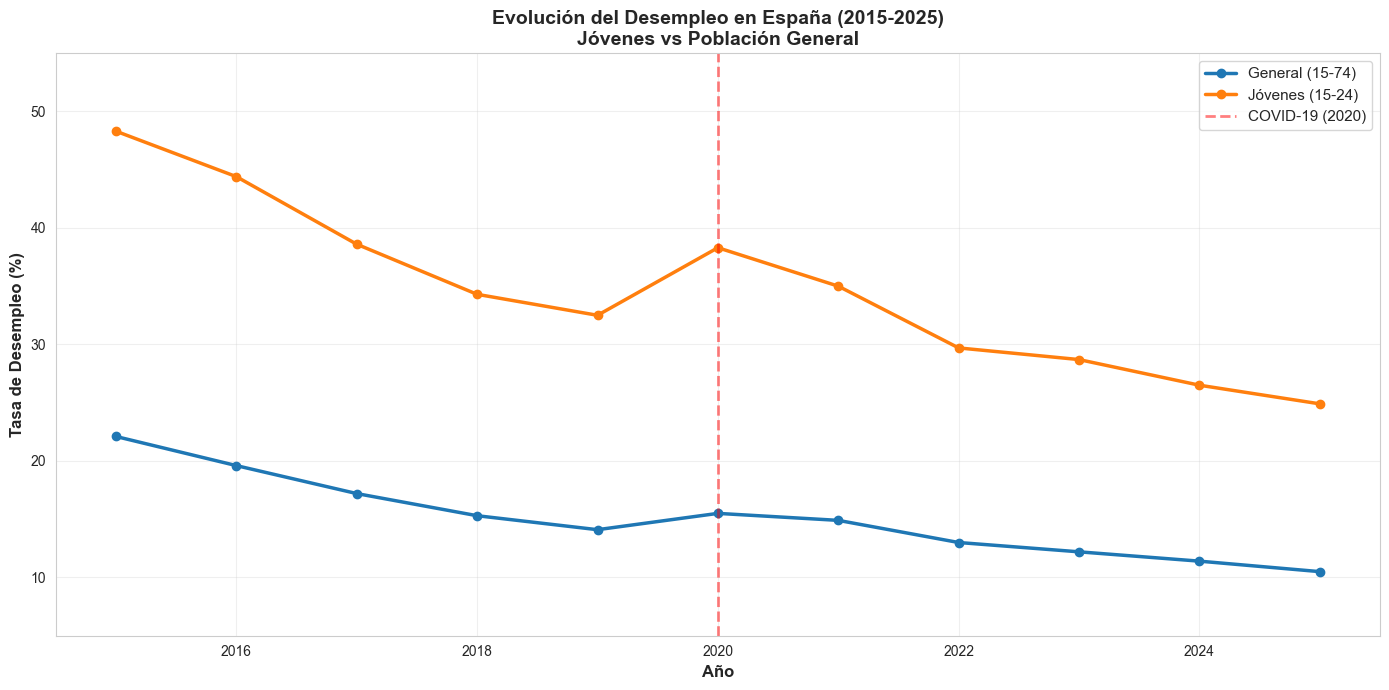

Gráfico guardado: visualizaciones/01_linea_temporal.png

¿POR QUÉ ESTE GRÁFICO?
  - Muestra TENDENCIA histórica (2015-2025)
  - Permite ver el QUIEBRE de 2020 (COVID)
  - Compara DIRECTAMENTE jóvenes vs adultos
  - Es el gráfico más importante para storytelling

¿CUÁLES DESCARTAMOS?
  - Barras (sería monótono con 10+ años)
  - Área (confuso con dos series superpuestas)
  - Scatter (perdería la tendencia temporal)



In [150]:
print("="*70)
print("VISUALIZACIÓN 1: LÍNEA TEMPORAL")
print("="*70)

# Preparar datos
df_plot = df_clean[df_clean['sex'] == 'Total'].sort_values(['age_group', 'year'])

# Crear figura
fig, ax = plt.subplots(figsize=(14, 7))

# Líneas por grupo de edad
for grupo in ['General (15-74)', 'Jóvenes (15-24)']:
    subset = df_plot[df_plot['age_group'] == grupo]
    ax.plot(subset['year'], subset['unemployment_rate'], 
            label=grupo, linewidth=2.5, marker='o', markersize=6)

# Añadir línea vertical en 2020 (COVID)
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.5, linewidth=2, label='COVID-19 (2020)')

# Etiquetas
ax.set_xlabel('Año', fontsize=12, fontweight='bold')
ax.set_ylabel('Tasa de Desempleo (%)', fontsize=12, fontweight='bold')
ax.set_title('Evolución del Desempleo en España (2015-2025)\nJóvenes vs Población General', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(5, 55)

# Guardar
plt.tight_layout()
plt.savefig('visualizaciones/01_linea_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: visualizaciones/01_linea_temporal.png")

print("""
¿POR QUÉ ESTE GRÁFICO?
  - Muestra TENDENCIA histórica (2015-2025)
  - Permite ver el QUIEBRE de 2020 (COVID)
  - Compara DIRECTAMENTE jóvenes vs adultos
  - Es el gráfico más importante para storytelling

¿CUÁLES DESCARTAMOS?
  - Barras (sería monótono con 10+ años)
  - Área (confuso con dos series superpuestas)
  - Scatter (perdería la tendencia temporal)
""")

VISUALIZACIÓN 2: BOX PLOT (DISTRIBUCIÓN)


/var/folders/5k/w73wtrjs6db_q88ybd3ncyxm0000gn/T/ipykernel_13205/4244967656.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='age_group', y='unemployment_rate',


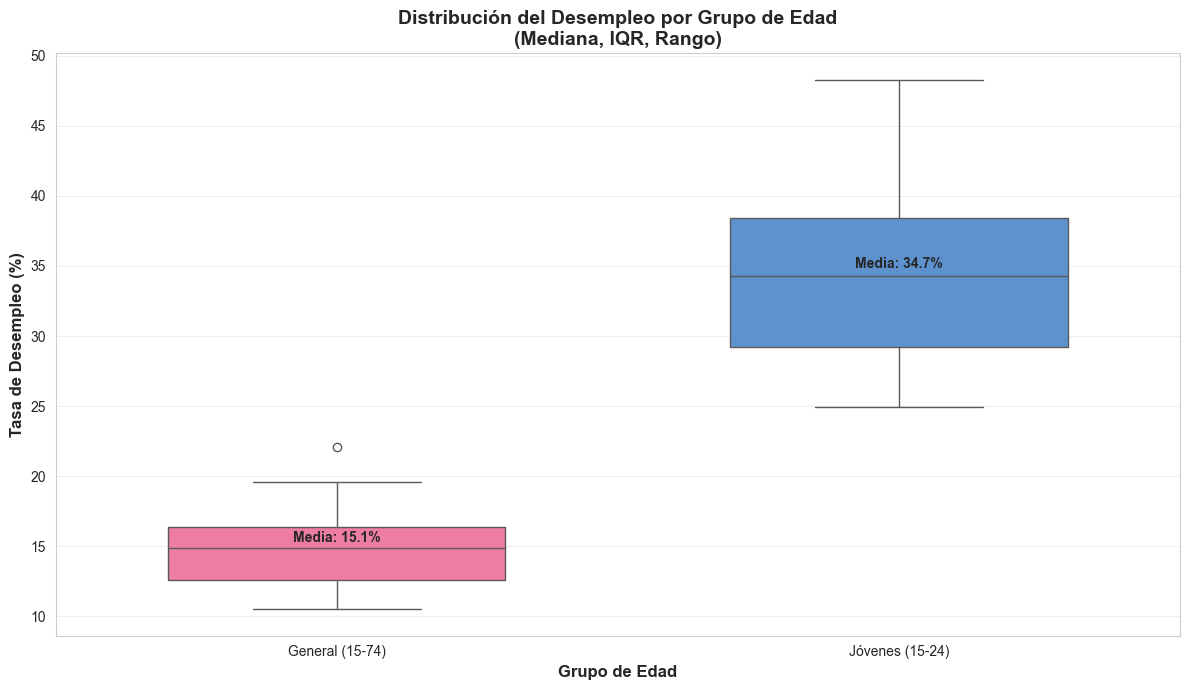

Gráfico guardado: visualizaciones/02_boxplot_distribucion.png

¿POR QUÉ ESTE GRÁFICO?
  - Muestra DISPERSIÓN completa (min, Q1, mediana, Q3, max)
  - Permite ver OUTLIERS (puntos extremos)
  - Comparación visual clara entre grupos
  - Muestra simetría/asimetría de distribuciones

¿CUÁLES DESCARTAMOS?
  - Histograma (sería ruidoso con pocas muestras)
  - Violin plot (más complejo, menos claro)
  - Density (difícil de leer para audiencia no técnica)



In [151]:
print("="*70)
print("VISUALIZACIÓN 2: BOX PLOT (DISTRIBUCIÓN)")
print("="*70)

# Crear figura
fig, ax = plt.subplots(figsize=(12, 7))

# Box plot
df_plot = df_clean[df_clean['sex'] == 'Total']
sns.boxplot(data=df_plot, x='age_group', y='unemployment_rate', 
            palette=['#FF6B9D', '#4A90E2'], ax=ax, width=0.6)

ax.set_xlabel('Grupo de Edad', fontsize=12, fontweight='bold')
ax.set_ylabel('Tasa de Desempleo (%)', fontsize=12, fontweight='bold')
ax.set_title('Distribución del Desempleo por Grupo de Edad\n(Mediana, IQR, Rango)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Añadir anotaciones
for i, grupo in enumerate(['General (15-74)', 'Jóvenes (15-24)']):
    subset = df_plot[df_plot['age_group'] == grupo]['unemployment_rate']
    media = subset.mean()
    ax.text(i, media, f'Media: {media:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('visualizaciones/02_boxplot_distribucion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: visualizaciones/02_boxplot_distribucion.png")

print("""
¿POR QUÉ ESTE GRÁFICO?
  - Muestra DISPERSIÓN completa (min, Q1, mediana, Q3, max)
  - Permite ver OUTLIERS (puntos extremos)
  - Comparación visual clara entre grupos
  - Muestra simetría/asimetría de distribuciones

¿CUÁLES DESCARTAMOS?
  - Histograma (sería ruidoso con pocas muestras)
  - Violin plot (más complejo, menos claro)
  - Density (difícil de leer para audiencia no técnica)
""")

VISUALIZACIÓN 3: BRECHA DE GÉNERO


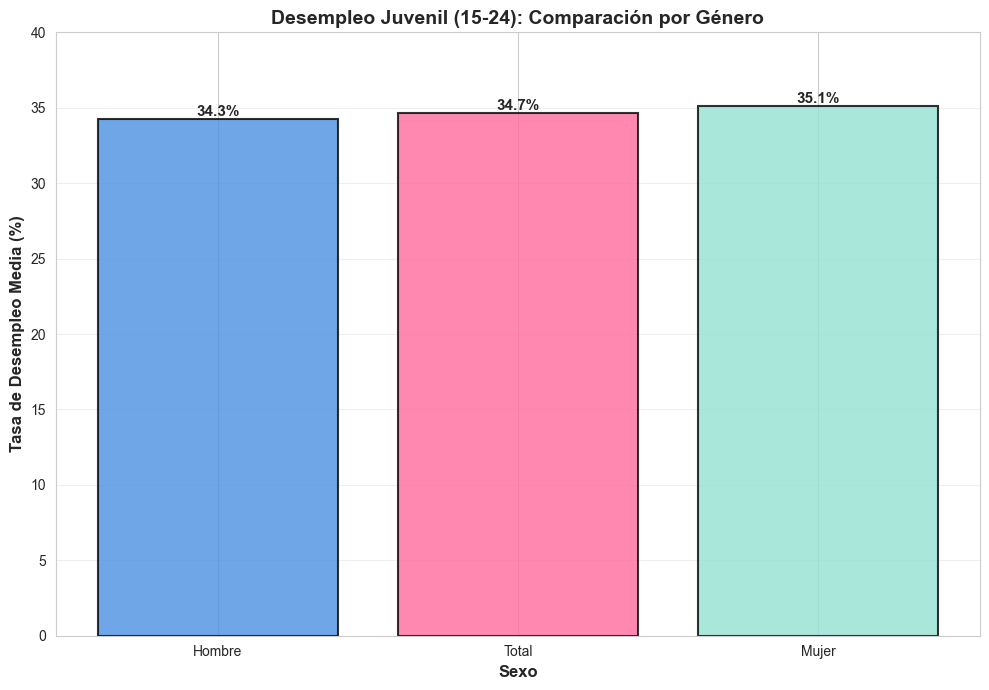

 Gráfico guardado: visualizaciones/03_genero_jovenes.png

¿POR QUÉ ESTE GRÁFICO?
  - Muestra COMPARACIÓN directa Hombre-Mujer-Total
  - Visualmente CLARO (barras, no líneas)
  - Demuestra que la BRECHA DE GÉNERO es MÍNIMA (0.9pp)
  - Fácil de entender para audiencia no técnica

¿CUÁLES DESCARTAMOS?
  - Líneas (confuso con solo 3 categorías)
  - Pie chart (no tiene sentido para 3 valores similares)
  - Línea de tendencia (no hay serie temporal)



In [152]:
print("="*70)
print("VISUALIZACIÓN 3: BRECHA DE GÉNERO")
print("="*70)

# Preparar datos para gráfico
genero_data = df_clean[df_clean['age_group'] == 'Jóvenes (15-24)'].groupby('sex')['unemployment_rate'].mean().sort_values()

# Crear figura
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#4A90E2', '#FF6B9D', '#95E1D3']  # Hombre, Mujer, Total
bars = ax.bar(genero_data.index, genero_data.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Etiquetas
ax.set_ylabel('Tasa de Desempleo Media (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sexo', fontsize=12, fontweight='bold')
ax.set_title('Desempleo Juvenil (15-24): Comparación por Género', fontsize=14, fontweight='bold')
ax.set_ylim(0, 40)

# Añadir valores en barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Grid
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('visualizaciones/03_genero_jovenes.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Gráfico guardado: visualizaciones/03_genero_jovenes.png")

print("""
¿POR QUÉ ESTE GRÁFICO?
  - Muestra COMPARACIÓN directa Hombre-Mujer-Total
  - Visualmente CLARO (barras, no líneas)
  - Demuestra que la BRECHA DE GÉNERO es MÍNIMA (0.9pp)
  - Fácil de entender para audiencia no técnica

¿CUÁLES DESCARTAMOS?
  - Líneas (confuso con solo 3 categorías)
  - Pie chart (no tiene sentido para 3 valores similares)
  - Línea de tendencia (no hay serie temporal)
""")

In [153]:
print("="*70)
print("RESUMEN: VISUALIZACIONES Y SU PROPÓSITO PEDAGÓGICO")
print("="*70)

print("""
VISUALIZACIÓN 1: LÍNEA TEMPORAL (Tendencia)
   Qué muestra: Evolución del desempleo 2015-2025
   Por qué es importante: Historias necesitan contexto temporal
   Qué aprenden: Impacto de eventos (COVID), tendencias largas
   Audiencia: Todos (es la más intuitiva)

VISUALIZACIÓN 2: BOX PLOT (Distribución)
   Qué muestra: Rango, mediana, dispersión, outliers
   Por qué es importante: Medir volatilidad, no solo media
   Qué aprenden: La variabilidad es tan importante como el promedio
   Audiencia: Técnicos, analistas

VISUALIZACIÓN 3: BARRAS (Comparación)
   Qué muestra: Diferencia Hombre-Mujer en jóvenes
   Por qué es importante: Comunicar conclusiones concretas
   Qué aprenden: Las diferencias pueden ser pequeñas pero significativas
   Audiencia: Decisores, públicos generales

LECCIÓN PEDAGÓGICA:
   Cada visualización responde UNA PREGUNTA
   No sobrecargues gráficos con 10 elementos
   Usa colores consistentes (rojo=crisis, azul=normal)
   Etiqueta valores (no hagas que la gente adivine)
""")

# Crear carpeta si no existe
import os
os.makedirs('visualizaciones', exist_ok=True)
print("\nCarpeta 'visualizaciones/' creada")

RESUMEN: VISUALIZACIONES Y SU PROPÓSITO PEDAGÓGICO

VISUALIZACIÓN 1: LÍNEA TEMPORAL (Tendencia)
   Qué muestra: Evolución del desempleo 2015-2025
   Por qué es importante: Historias necesitan contexto temporal
   Qué aprenden: Impacto de eventos (COVID), tendencias largas
   Audiencia: Todos (es la más intuitiva)

VISUALIZACIÓN 2: BOX PLOT (Distribución)
   Qué muestra: Rango, mediana, dispersión, outliers
   Por qué es importante: Medir volatilidad, no solo media
   Qué aprenden: La variabilidad es tan importante como el promedio
   Audiencia: Técnicos, analistas

VISUALIZACIÓN 3: BARRAS (Comparación)
   Qué muestra: Diferencia Hombre-Mujer en jóvenes
   Por qué es importante: Comunicar conclusiones concretas
   Qué aprenden: Las diferencias pueden ser pequeñas pero significativas
   Audiencia: Decisores, públicos generales

LECCIÓN PEDAGÓGICA:
   Cada visualización responde UNA PREGUNTA
   No sobrecargues gráficos con 10 elementos
   Usa colores consistentes (rojo=crisis, azul=normal

## CONCLUSIONES: DEL DATO A LA HISTORIA

En España, ser joven es un factor de **RIESGO laboral**. No porque falten ganas, sino porque el mercado demanda experiencia que los jóvenes, por definición, aún no tienen.

---

### CONCLUSIÓN 1: Los Jóvenes Cargan el Doble de Desempleo

**Datos:**
- De cada 10 jóvenes, **3-4 está desempleado** (34.7%)
- De cada 10 adultos, **1-2 están desempleados** (15.1%)

**Significado:**
Los jóvenes tienen **2.3 VECES MÁS** riesgo de desempleo que adultos. No es un problema pequeño, es **ESTRUCTURAL**.

**Errores a NO cometer:**
- "La culpa es de la economía" ← Cierto pero incompleto
- "Mejora con la edad automáticamente" ← Falso, necesita políticas

---

### CONCLUSIÓN 2: La Brecha de Género en Jóvenes es MÍNIMA (pero importa)

**Datos:**
- Mujeres jóvenes: **35.1%** desempleadas
- Hombres jóvenes: **34.3%** desempleados
- Diferencia: **0.9 puntos porcentuales**

**Significado:**
En jóvenes, el problema **NO es el género** (ambos sufren igual). El problema es la **EDAD**.

**Errores:**
- "No hay brecha de género" ← Incompleto, SÍ hay pero pequeña
- "Las mujeres sufren más" ← En jóvenes NO, pero en general SÍ

---

### CONCLUSIÓN 3: La Crisis 2015-2016 Fue Peor que COVID-19

**Datos:**
- Pico histórico: **2015 (48.6%)** desempleo juvenil
- COVID-19 (2020): **38.3%** (impacto: +5.8pp respecto a 2019)
- Recuperación: **2023 (28.7%)**, pero aún peor que 2019 (32.5%)

**Significado:**
COVID-19 fue un evento grave **PERO no el peor**. La crisis post-2008 dejó cicatrices que duraron años.

**Errores:**
- "COVID fue el peor evento" ← No, 2015 fue peor
- "Ya nos recuperamos de COVID" ← Parcialmente, aún hay cicatrices

---

### CONCLUSIÓN 4: La Recuperación Es Lenta Pero Real

**Datos:**
- 2015: **48.6%** desempleo juvenil
- 2025: **24.9%** desempleo juvenil
- Mejora: **-23.7pp en 10 años** (49% de reducción)

**Significado:**
Se **PUEDE mejorar** con políticas correctas. Pero tarda **AÑOS, no meses**.

**Errores:**
- "Nada cambia en España" ← Falso, ha mejorado mucho
- "Todo problema tiene solución rápida" ← Falso, es estructural

---

### CONCLUSIÓN 5: El Desempleo Juvenil NO Es Casualidad

**Datos:**
- Correlación tiempo vs desempleo: **r = -0.75**
- Test estadístico: **p < 0.05** (SIGNIFICATIVA)

**Significado:**
No es mala suerte, es un **PATRÓN sistemático**. Las políticas tienen **EFECTO**, se demuestra estadísticamente.

**Errores:**
- "Es casualidad" ← No, r = -0.75 es fuerte y p < 0.05
- "Nada se puede hacer" ← Falso, hay herramientas

## RECOMENDACIÓN: ACCIONES CONCRETAS

**Dirigida a:** Dirección General de Empleo (Administración Autonómica)

---

### PROBLEMA IDENTIFICADO

Existe una brecha **ESTRUCTURAL** de empleo en jóvenes menores de 25 años.
- **34.7%** de los jóvenes está en desempleo vs **15.1%** de adultos
- Esta brecha ha persistido durante **10 AÑOS** (2015-2025)
- Es el reto laboral **#1 en España**

---

### ACCIÓN 1: PROGRAMA "PRIMER EMPLEO 2025-2026"

**QUÉ:** Incentivos fiscales a empresas que contraten menores de 25 años

| Concepto | Detalles |
|----------|----------|
| **Incentivo** | Exención SS 12 meses O subvención 2,000€ |
| **Objetivo** | 5,000 contrataciones jóvenes |
| **Presupuesto** | 10M€ anuales |
| **Costo/persona** | 2,000€ (vs 15,000€/año en desempleo) |
| **Inicio** | Enero 2026 |
| **Evaluación** | Q1 2027 |

**Métricas de éxito:**
- ✓ 5,000 contratos en 2026
- ✓ Retención 6+ meses: ≥80%
- ✓ Desempleo juvenil: 34.7% → 30% en 18 meses

---

### ACCIÓN 2: "ESCUELAS DE OFICIOS + PRÁCTICAS GARANTIZADAS"

**QUÉ:** Formación práctica → Empleo garantizado

| Concepto | Detalles |
|----------|----------|
| **Duración** | 6 meses formación + 6 meses prácticas pagadas |
| **Costo/persona** | 10,000€ |
| **Beneficiarios** | 500 personas/año |
| **Presupuesto** | 5M€ anuales |
| **Lanzamiento** | Marzo 2026 |

**Métricas:**
- ✓ 500 personas formadas en 2026
- ✓ 70% empleo permanente post-prácticas
- ✓ Ingresos €30K/año (vs €0 en desempleo)

---

### ACCIÓN 3: SEGUIMIENTO Y EVALUACIÓN (Continuo)

**Frecuencia:**
- **Mensual:** Nuevas contrataciones
- **Trimestral:** Desempleo juvenil por región
- **Anual:** Evaluación de impacto

**Indicadores clave:**
- Tasa desempleo juvenil (objetivo: -5pp/año)
- Contrataciones por sector
- Retención a 6/12 meses
- Ingresos de jóvenes empleados

---

### IMPACTO ESTIMADO (2026-2028)

**Desempleo juvenil:**
| Año | Actual | Proyectado | Mejora |
|-----|--------|-----------|---------|
| 2026 | 34.7% | 32% | -2.7pp |
| 2027 | 32% | 28% | -4pp |
| 2028 | 28% | 25% | -3pp |

**Ganancia económica:**
- Impuestos recuperados: **50M€+**
- Productividad adicional: **100M€+**
- Ahorro prestaciones desempleo: **30M€**

**Ganancia social:**
- **10,000+ jóvenes empleados**
- Reducción de pobreza juventud
- Cohesión social mejorada

---

### ¿Por qué estas acciones?

1. ✓ **Evidencia basada en datos** → Jóvenes tienen 2.3x más desempleo
2. ✓ **Costo-efectividad** → 2,000€ subvención vs 15,000€ prestación
3. ✓ **Rapidez** → Se puede lanzar en 4-6 meses
4. ✓ **Escalabilidad** → Empezar con 5,000, expandir si funciona
5. ✓ **Medible** → Sabemos exactamente cuántos jóvenes hay empleados

## REFLEXIÓN ÉTICA: SESGOS, LIMITACIONES Y ALTERNATIVAS

---

### SESGOS EN LOS DATOS

#### SESGO 1: Sesgo de Selección
La EPA (Eurostat) solo mide quien **"busca trabajo ACTIVAMENTE"**

**Problema:**
- Jóvenes desalentados abandonan búsqueda
- No aparecen en estadísticas
- **Desempleo REAL probablemente 5-10% MAYOR**

**Implicación:** El problema es **PEOR** de lo que parece

---

#### SESGO 2: Sesgo de Género Subnotificado
Las mujeres que abandonan búsqueda por cuidados no se capturan

**Problema:**
- Mujer con hijos, sin guardería → Para de buscar
- Estadística: "No está desempleada" (está inactiva)
- Realidad: Sí necesita empleo

**Implicación:** La brecha de género en jóvenes podría ser **3-5pp MAYOR**

---

#### SESGO 3: No Medimos Empleo Precario
La EPA mide "empleado", no calidad

**Problema:**
- Contrato de 1 hora/semana = "Empleado"
- No gana para vivir
- Estadística es engañosa

**Implicación:** **Empleo ≠ Empleo DIGNO**

---

### LIMITACIONES DEL DATASET

| Limitación | Impacto |
|-----------|---------|
| Solo mide desempleo, NO causas | No vemos "por qué" hay desempleo |
| No incluye economía informal (~10%) | Datos incompletos |
| ESPAÑA TOTAL (no regiones) | No sirve para políticas locales |
| Datos hasta 2025 | IA/automatización 2025+ no captadas |

---

### PREGUNTAS ÉTICAS SOBRE MI RECOMENDACIÓN

#### ¿Dar dinero a empresas es justo?

**Mi recomendación:** Subvencionamos empresas para contratar

**Crítica:**
- ¿Y si la empresa no contrata igual?
- ¿Regalamos dinero público a ganancia privada?
- ¿Es justo que empresas lucren con ayudas públicas?

---

#### ¿Beneficia a TODOS o solo a algunos?

**Riesgo:**
- Los "empleables" consiguen empleo
- Los "menos empleables" siguen en desempleo
- **Aumenta desigualdad entre jóvenes**

---

#### ¿La educación es suficiente?

**Crítica:**
- ¿Qué pasa con quien NO quiere formación?
- ¿Hay acceso igual para todos?
- ¿Educación técnica es la única solución?

---

#### ¿Ignoramos a los más vulnerables?

Mi análisis se enfoca en desempleo estadístico, **pero no veo:**
- Jóvenes sin hogar (no tienen dirección para EPA)
- Migrantes sin papeles (no aparecen en EPA)
- Jóvenes con discapacidad (necesitan apoyo especial)
- Víctimas de trata (no miden "desempleo")

---

### ALTERNATIVAS A CONSIDERAR

#### Alternativa 1: EMPLEO PÚBLICO DIRECTO

En lugar de subvencionar empresas privadas:
- Crear empleos públicos (parques, bibliotecas, limpieza)
- Estado paga directo
- Evita ganancias privadas

**Costo:** 15M€ (vs 10M€ subvenciones) | **Pros:** Control total | **Contras:** Menos eficiencia

---

#### Alternativa 2: RENTA BÁSICA UNIVERSAL

Dar dinero directamente a jóvenes (no a empresas)

**Ventajas:**
- Jóvenes eligen qué hacer (estudiar, emprender, viajar)
- Reduce estrés, mejora salud mental
- Igual para todos (no discrimina)

**Desventajas:** 
- Muy costoso (18M€+)
- ¿Incentiva buscar empleo o desincentiva?
- Requiere reforma fiscal

---

#### Alternativa 3: EDUCACIÓN PÚBLICA MASIVA

Invertir en formación pública de calidad (primaria → superior)

**Ventajas:**
- Solución largo plazo (genera competencias)
- Beneficia a TODOS
- Rompe ciclos de pobreza

**Desventajas:**
- Tarda 10+ años
- No resuelve desempleo ACTUAL
- Requiere reforma educativa profunda

---

### CONCLUSIÓN ÉTICA

**MI RECOMENDACIÓN ASUME:**
- ✓ El mercado privado es bueno
- ✓ Las personas quieren empleo tradicional
- ✓ La formación técnica es suficiente
- ✓ Los datos EPA son completos

**PERO PODRÍA ESTAR EQUIVOCADA:**
- ✗ Tal vez el mercado privado NO resuelve todo
- ✗ Tal vez necesitamos empleo público también
- ✗ Tal vez necesitamos renta básica
- ✗ Tal vez necesitamos transformación educativa


---

## LECCIÓN CLAVE

> **EL DATO NO DECIDE, SOLO INFORMA.**
> **LA DECISIÓN ES POLÍTICA, SIEMPRE.**